# Data Exploration  
Data exploration is a crucial first step in any machine learning workflow, helping data scientists understand the structure, quality, and patterns in the data. In this note, we will perform the following data exploration steps.    

- Read  
- Inspect   
- Subset  
- Edit  
- Summarize  
- Visualize  


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Read Data  
Pandas has a number of read_ functions to ingest data from a number of different data formats. We will rely on the read_csv() function as most datasets come in a text based comma-separated values format. However, it is worth mentioning that binary formats like parquet tend to be much more compact than text-based files and they do a better job saving additional meta data like variable types. 

In [27]:
import pandas
for fname in dir(pandas):
    if not fname.startswith('read_'):
        continue
    print(fname)

read_clipboard
read_csv
read_excel
read_feather
read_fwf
read_gbq
read_hdf
read_html
read_json
read_orc
read_parquet
read_pickle
read_sas
read_spss
read_sql
read_sql_query
read_sql_table
read_stata
read_table
read_xml


### Data  

This dataset contains information about companies in the S&P 500 index. Specifically, the dataset combines basic company information, such as company name, industry, headquarters location, and founding year, with selected financial and business metrics, including revenue, gross profit, operating income, net income, number of employees, and market capitalization. Data is in sp500_firms.csv

## Variable Descriptions
* `symbol`: Stock ticker symbol for the company. Example: AAPL, MSFT, JPM.
* `company_name`: Official company name. Example: Apple Inc., Microsoft Corporation, JPMorgan Chase & Co.
* `industry`: Industry or sub-industry classification for the company. Example: Technology Hardware, Pharmaceuticals, Regional Banks.
* `headquarters_city`: City where the company’s headquarters is located. Example: New York, Cupertino, Seattle.
* `headquarters_state`: State where the company’s headquarters is located. Example: New York, California, Washington.
* `founded_year`: Year the company was founded. This can be used to calculate company age.
* `revenue`: Total sales or revenue reported by the company for the most recent annual period available.
* `gross_profit`: Revenue minus cost of goods sold. This measures profit before operating expenses, interest, and taxes.
* `operating_income`: Profit from the company’s core business operations after operating expenses are deducted.
* `net_income`: Final profit after all expenses, taxes, interest, and other items are included.
* `employees`: Number of employees reported by the company. Some values may be missing because employee counts are not always consistently available.
* `market_cap`: Market capitalization, or the total stock market value of the company. It is calculated as stock price multiplied by shares outstanding.


In [28]:
companies = pd.read_csv(filepath_or_buffer='sp500_companies.csv')

## Inspect Data   
Examine data to gain insight on size, structure, data types, completeness, consistency, encoding, and descriptive statistics. 

- .head(), .tail(): First few, last few rows
- .info(): Structure of Data
- .dtypes: Data type of each column/variable. Pandas refers to string as object. If the data contains missing values (NaN), the column is treated as a floating point data type (as opposed to say integer).
- .describe(): Summary statistics
- .shape: rows and columns
- .columns: List of all column indices
- .index: row index
- .axes: List of all indices. This would include row indices and column indices for a two-dimensional structure.
- .values(): Convert to numpy array
- .value_counts(): Frequency of categorical variables
- .selectdtypes(), .astype(): Verify data type has been parsed correctly. Correct if needed. 


In [ ]:
# First few, last few rows

In [29]:
# Structure of the Data

In [30]:
# Data types of columns

In [20]:
# Summary statistics

In [21]:
# Dimensions of data

In [22]:
# Column Names

In [23]:
# Row index

In [24]:
# Row and Column indices

In [25]:
# Convert to numpy array

In [32]:
# Frequency of categorical variables

industry
Health Care Equipment                           16
Electric Utilities                              15
Application Software                            15
Semiconductors                                  14
Industrial Machinery & Supplies & Components    14
                                                ..
Single-Family Residential REITs                  1
Technology Distributors                          1
Specialized Consumer Services                    1
Timber REITs                                     1
Water Utilities                                  1
Name: count, Length: 127, dtype: int64

In [37]:
 # verify data types have been parsed correctly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   symbol              503 non-null    object 
 1   company_name        503 non-null    object 
 2   industry            503 non-null    object 
 3   headquarters_city   503 non-null    object 
 4   headquarters_state  502 non-null    object 
 5   founded_year        464 non-null    float64
 6   revenue             490 non-null    float64
 7   gross_profit        253 non-null    float64
 8   operating_income    416 non-null    float64
 9   net_income          502 non-null    float64
 10  employees           13 non-null     float64
 11  market_cap          467 non-null    float64
dtypes: float64(7), object(5)
memory usage: 47.3+ KB


## Subset  
Machine learning problems often involve choosing relevant features and using observations that meet analysis requirements.  

- .head(n) will pull the first n elements. Default for n is 5 
- .tail(n) will pull the last n elements.
- select variables
  - Square brackets for one or more variables. `df['col1']` or `df[['col1','col2','col3']]`
  - .column_name for one variable. `df.col_1`
  - .select_dtypes() to select variables of a certain type
- extract data with `.iloc`
- extract data with `.loc`
- boolean subsetting
- sample rows or columns

In [38]:
# First few rows

In [39]:
# Last few rows

In [40]:
# Select company_name for first five rows

Index(['symbol', 'company_name', 'industry', 'headquarters_city',
       'headquarters_state', 'founded_year', 'revenue', 'gross_profit',
       'operating_income', 'net_income', 'employees', 'market_cap'],
      dtype='object')

In [ ]:
# Select company_name and revenue for first five rows

In [ ]:
# Select all numeric variables for first five rows

### Subset by Index: `.iloc`
- The iloc accessor retrieves one or more rows by row-column index position.
- iloc is short for index location
- Provide a pair of square brackets after the accessor
- iloc accepts single values, lists, and slices.
* Python's list slicing syntax is supported with DataFrame objects
* Syntax: `df.iloc[:4, [1,3]]`

In [42]:
# Select symbol, company_name, and net_income for first 10 rows. 

#### Index  
- Understanding the meaning of an Index is critical to understanding extracting data with `.iloc`
- The index serves as the collection of primary identifiers for the rows
- The default index can be changed using set_index() method which sets an existing column as the index of the DataFrame
- .reset_index() method sets the standard ascending numeric index as the index of the DataFrame
- The fastest way to extract a row is from a sorted index by position/label
- Pandas uses index labels/values when merging different objects together
- An index can contain more than one column

In [110]:
# companies.set_index('symbol').head()

In [111]:
# companies.set_index(['symbol','company_name']).head()

In [112]:
# companies.set_index(['symbol','company_name']).reset_index().head()

### Subset by Index Label: `.loc`
- Use the loc accessor to extract one or more row index label
- Pass a list to extract multiple values by index label
- Syntax: `df.loc[row_index1:row_index2, ['col1','col2','col3']]`
- Order of columns in square brackets is the order of columns in resulting data frame
- This process generates a copy, not a view.

In [114]:
# Select symbol, company_name, and net_income for first 10 rows. 

In [115]:
# companies.loc[companies.symbol.isin(['AMZN','META']),:]  # do not run this.. look at it after boolean subsetting

#companies_with_index = companies.set_index('symbol')
#companies_with_index.loc[['AMZN','META'],['company_name','market_cap']]

- Once an index has been set, the default numerical index will not work. 
- Default index can be passed to .iloc.

In [116]:
# companies_with_index.loc[[22,309],['company_name','market_cap']]   # this will generate an error

# companies.loc[[22,309],['company_name','market_cap']]  # this will work


### Boolean Subsetting
- DataFrames can be subset by passing it a set of Booleans
- Most data analysis involves subsetting based on a condition
- Filter using multiple conditions using and & or !

In [117]:
# How many S&P 500 firms are worth more than 1 Trillion dollars

# First generate a boolean index for market cap greater than 1 Trillion
# Use the boolean index to subset using .loc



In [118]:
# How many S&P 500 firms are worth more than 1 Trillion dollars but have revenue less more than 100 Billion


In [119]:
#companies.set_index('company_name').filter(like = 'Tech', axis = 0)   # companies with Tech in the name

In [109]:
# companies.filter(like = 'income', axis = 1).head()    # columns with "income" in the name

### Random Sample 
.sample() will draw a random sample of rows or columns

In [124]:
# companies.sample(n=5, random_state=617, axis = 0)

## Edit Data  
This is essential for making datasets cleaner, more interpretable, and analysis-ready.  

- rename variables
- add new variables
- missing values
- change dtype
- sort
- delete rows or columns

### Rename Variables
- .rename() accepts a dictionary of for either its columns or index parameters
- The dictionary keys represent the existing names and the values represent the new names
- We can replace all columns by overwriting the DataFrame's columns attribute

In [125]:
companies

,symbol,company_name,industry,headquarters_city,headquarters_state,founded_year,revenue,gross_profit,operating_income,net_income,employees,market_cap
0,MMM,3M,Industrial Conglomerates,Saint Paul,Minnesota,1902.0,2.494800e+10,NaN,4.629000e+09,3.250000e+09,NaN,8.019618e+10
1,AOS,A. O. Smith,Building Products,Milwaukee,Wisconsin,1916.0,3.830200e+09,1.487400e+09,7.286000e+08,5.462000e+08,NaN,7.883798e+09
2,ABT,Abbott Laboratories,Health Care Equipment,North Chicago,Illinois,1888.0,4.432800e+10,4.397000e+09,8.053000e+09,6.524000e+09,NaN,1.586269e+11
3,ABBV,AbbVie,Biotechnology,North Chicago,Illinois,NaN,6.116000e+10,1.206600e+10,1.507500e+10,1.816000e+09,NaN,4.014683e+11
4,ACN,Accenture,IT Consulting & Other Services,Dublin,Ireland,1989.0,1.759626e+10,NaN,2.049691e+09,1.413963e+09,NaN,1.097013e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrial Machinery & Supplies & Components,White Plains,New York,2011.0,9.035000e+09,3.475000e+09,1.223000e+09,9.570000e+08,NaN,2.613202e+10
499,YUM,Yum! Brands,Restaurants,Louisville,Kentucky,1997.0,8.214000e+09,NaN,2.574000e+09,1.559000e+09,NaN,4.158297e+10
500,ZBRA,Zebra Technologies,Electronic Equipment & Instruments,Lincolnshire,Illinois,1969.0,5.396000e+09,2.593000e+09,7.000000e+08,4.190000e+08,NaN,1.105619e+10
501,ZBH,Zimmer Biomet,Health Care Equipment,Warsaw,Indiana,1927.0,8.231500e+09,1.285400e+09,1.098100e+09,7.051000e+08,NaN,1.689508e+10


In [126]:
companies \
    .rename(columns = {'headquarters_state': 'state', 
                       'headquarters_city': 'city'}) \
    .head()

,symbol,company_name,industry,city,state,founded_year,revenue,gross_profit,operating_income,net_income,employees,market_cap
0,MMM,3M,Industrial Conglomerates,Saint Paul,Minnesota,1902.0,2.494800e+10,NaN,4.629000e+09,3.250000e+09,NaN,8.019618e+10
1,AOS,A. O. Smith,Building Products,Milwaukee,Wisconsin,1916.0,3.830200e+09,1.487400e+09,7.286000e+08,5.462000e+08,NaN,7.883798e+09
2,ABT,Abbott Laboratories,Health Care Equipment,North Chicago,Illinois,1888.0,4.432800e+10,4.397000e+09,8.053000e+09,6.524000e+09,NaN,1.586269e+11
3,ABBV,AbbVie,Biotechnology,North Chicago,Illinois,NaN,6.116000e+10,1.206600e+10,1.507500e+10,1.816000e+09,NaN,4.014683e+11
4,ACN,Accenture,IT Consulting & Other Services,Dublin,Ireland,1989.0,1.759626e+10,NaN,2.049691e+09,1.413963e+09,NaN,1.097013e+11


### Add New Variables
- Use square bracket syntax with assignment operator to add append a new variable to a DataFrame
- .insert() can be used to specify the location where one wants to insert the new column(s). Existing columns are shifted to the right, not replaced
- .assign() is a handy way to add new column(s) without updating the original dataframe

In [136]:
# companies['gross_margin'] = (companies.gross_profit/companies.revenue)*100

In [137]:
# companies.assign(market_cap_trillions = companies.market_cap/1e12)

In [138]:
# companies_new_column = companies
# companies_new_column.insert(loc = 2, column = 'data_year',value = 2026)

### Missing Values
- Pandas uses NaN to indicate a missing number
- .dropna() deletes rows with missing values. Default is to remove entire row, if even one value in row is missing. 
- set how = 'all' to delete rows where all values are NaN
- subset parameter limits the columns that pandas will used to drop rows with missing values

In [139]:
#companies.isna().sum()   # How many missing values are in this dataset

symbol                  0
company_name            0
data_year               0
industry                0
headquarters_city       0
headquarters_state      1
founded_year           39
revenue                13
gross_profit          250
operating_income       87
net_income              1
employees             490
market_cap             36
dtype: int64

In [141]:
#(companies.isna().sum() /len(companies))*100   # % missing values

symbol                 0.000000
company_name           0.000000
data_year              0.000000
industry               0.000000
headquarters_city      0.000000
headquarters_state     0.198807
founded_year           7.753479
revenue                2.584493
gross_profit          49.701789
operating_income      17.296223
net_income             0.198807
employees             97.415507
market_cap             7.157058
dtype: float64

In [143]:
#companies[['revenue','net_income']].dropna(axis = 0).head()   # drop entire rows with any missing values

,revenue,net_income
0,2.494800e+10,3.250000e+09
1,3.830200e+09,5.462000e+08
2,4.432800e+10,6.524000e+09
3,6.116000e+10,1.816000e+09
4,1.759626e+10,1.413963e+09


In [146]:
# companies.dropna(axis = 0,how='all').head()                  # Only drop rows that are missing all values for a row

,symbol,company_name,data_year,industry,headquarters_city,headquarters_state,founded_year,revenue,gross_profit,operating_income,net_income,employees,market_cap
0,MMM,3M,2026,Industrial Conglomerates,Saint Paul,Minnesota,1902.0,2.494800e+10,NaN,4.629000e+09,3.250000e+09,NaN,8.019618e+10
1,AOS,A. O. Smith,2026,Building Products,Milwaukee,Wisconsin,1916.0,3.830200e+09,1.487400e+09,7.286000e+08,5.462000e+08,NaN,7.883798e+09
2,ABT,Abbott Laboratories,2026,Health Care Equipment,North Chicago,Illinois,1888.0,4.432800e+10,4.397000e+09,8.053000e+09,6.524000e+09,NaN,1.586269e+11
3,ABBV,AbbVie,2026,Biotechnology,North Chicago,Illinois,NaN,6.116000e+10,1.206600e+10,1.507500e+10,1.816000e+09,NaN,4.014683e+11
4,ACN,Accenture,2026,IT Consulting & Other Services,Dublin,Ireland,1989.0,1.759626e+10,NaN,2.049691e+09,1.413963e+09,NaN,1.097013e+11


### Replace Missing Values
* Replace missing values (None and NaN) with a specific value
* Works with both Series and DataFrame
* .fillna() resturns a copy of the original data 

In [148]:
# companies.net_income.fillna(value = companies.net_income.median())    # replacing missing values is risky business

0      3.250000e+09
1      5.462000e+08
2      6.524000e+09
3      1.816000e+09
4      1.413963e+09
           ...     
498    9.570000e+08
499    1.559000e+09
500    4.190000e+08
501    7.051000e+08
502    2.673000e+09
Name: net_income, Length: 503, dtype: float64

One may not want to use the same replacement value for all data types. One solution is to extract a series and fillna for only that column. Since .fillna() creates a copy, we will assign the result back to the column of team_salary

### Change Type of a Series
* The astype method converts a Series values to a specified type
* Pass the specified type as either a string ro the core Python data type
* Pandas cannot convert NaN values to numeric types, so these need to be eliminated before we perform type conversion

In [156]:
# companies.market_cap.dropna().astype(int)

0       80196182016
1        7883797504
2      158626922496
3      401468325888
4      109701316608
           ...     
498     26132023296
499     41582972928
500     11056186368
501     16895078400
502     33303484416
Name: market_cap, Length: 467, dtype: int64

### Sort a DataFrame
* `.sort_values()` method can be used to sort a DataFrame by values in one or more columns
* Default sort order is ascending. `ascending = True`
* Select column to use for sorting using `by` parameter
* Sort order can be customized for each column by providing ascending argument a list. `ascending = [True, False, True]`
* Missing values may be placed at the start or end by specifying `na_position`
* `.sort_index()` method can be used to sort by index

In [159]:
# Sort company_name and market_cap in descending order of market cap. 

In [ ]:
# .sort_index() # Sort data in alphabetical order of company_name. 

### Delete Rows or Columns
- The .drop() method deletes one or more rows/columns
- Pass the index or columns parameters a list of the column names to remove.
- The .pop() method removes and returns a single Series (it mutates the DataFrame in the process).
- Python's del keyword also removes a single Series.


In [162]:
# companies.drop(columns = 'employees').head()

,symbol,company_name,data_year,industry,headquarters_city,headquarters_state,founded_year,revenue,gross_profit,operating_income,net_income,market_cap
0,MMM,3M,2026,Industrial Conglomerates,Saint Paul,Minnesota,1902.0,2.494800e+10,NaN,4.629000e+09,3.250000e+09,8.019618e+10
1,AOS,A. O. Smith,2026,Building Products,Milwaukee,Wisconsin,1916.0,3.830200e+09,1.487400e+09,7.286000e+08,5.462000e+08,7.883798e+09
2,ABT,Abbott Laboratories,2026,Health Care Equipment,North Chicago,Illinois,1888.0,4.432800e+10,4.397000e+09,8.053000e+09,6.524000e+09,1.586269e+11
3,ABBV,AbbVie,2026,Biotechnology,North Chicago,Illinois,NaN,6.116000e+10,1.206600e+10,1.507500e+10,1.816000e+09,4.014683e+11
4,ACN,Accenture,2026,IT Consulting & Other Services,Dublin,Ireland,1989.0,1.759626e+10,NaN,2.049691e+09,1.413963e+09,1.097013e+11


### .apply() with DataFrame
- The apply method invokes a function on every column or every row in the DataFrame.
- Pass the uninvoked function as the first argument to .apply() method.
- Pass the axis parameter an argument of "columns" to invoke the function on every row.
- Pandas will pass in the row's values as a Series object. We can use accessors like loc and iloc to extract the column's values for that row.

In [165]:
# companies.apply(len, axis = 0)

symbol                503
company_name          503
data_year             503
industry              503
headquarters_city     503
headquarters_state    503
founded_year          503
revenue               503
gross_profit          503
operating_income      503
net_income            503
employees             503
market_cap            503
dtype: int64

## Summarize  
This helps uncover patterns, distributions, and anomalies.  

- Overall summary using .describe()
- Summarize categorical variables using .value_counts(), .dtype category
- Grouped operations using .groupby()

### Overall Summary

In [72]:
# companies.describe(include='all')

,Company,Sector,Industry,Number_of_employees,Revenues_M,Profits_M,MarketCap_Updated_M
count,1000,1000,1000,1.000000e+03,1000.000000,998.000000,9.630000e+02
unique,1000,21,75,NaN,NaN,NaN,NaN
top,Walmart,Financials,Commercial Banks,NaN,NaN,NaN,NaN
freq,1,163,37,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.661176e+04,20965.064200,1867.165832,5.397445e+04
std,NaN,NaN,NaN,9.990100e+04,48589.311028,6649.887738,2.292664e+05
min,NaN,NaN,NaN,2.800000e+01,2489.000000,-10298.000000,1.000000e+00
25%,NaN,NaN,NaN,6.718000e+03,3968.375000,157.575000,4.832500e+03
50%,NaN,NaN,NaN,1.400000e+04,7090.500000,542.600000,1.237900e+04
75%,NaN,NaN,NaN,3.074075e+04,16207.650000,1401.050000,3.773550e+04


### Numeric Variables    
Common aggregation methods are   
- Frequency   
    - Count              | df.var.count()   
- Measures of central tendency   
    - Mean               | df.var.mean()   
    - Median             | df.var.median()    
    - Mode               | df.var.mode()   
- Measures of dispersion  
    - Maximum            | df.var.max()  
    - Minimum            | df.var.min()  
    - Standard Deviation | df.var.std()  
    - Variance           | df.var.var()  
- Shape of Distribution  
    - Skewness           | df.var.skew()  
    - Kurtosis           | df.var.kurt()  
  
To use multiple aggregation functions, use agg interface  
- Mean and Median: df['var'].agg(['mean','median'])  

In [166]:
#print(
#    'sum:', companies.revenue.sum(),'\n'+
#    'frequency:', companies.revenue.count(),'\n'+
#    'mean:', companies.revenue.mean(),'\n'+  
#    'median:',companies.revenue.median(),'\n'+
#    'mode:', companies.revenue.mode(),'\n'+
#    'maximum:', companies.revenue.max(),'\n'+
#    'minimum:', companies.revenue.min(),'\n'+
#    'standard deviation:', companies.revenue.std(),'\n'+
#    'variance:', companies.revenue.var(),'\n'+
#    'skew:', companies.revenue.skew(),'\n'+
#    'kurtosis:', companies.revenue.kurt()
#)

sum: 16389945902000.0 
frequency: 490 
mean: 33448869187.7551 
median: 12330910000.0 
mode: 0    8.452000e+09
1    1.226900e+10
2    1.630000e+10
3    3.500180e+11
Name: revenue, dtype: float64 
maximum: 716924000000.0 
minimum: 7042000.0 
standard deviation: 72252780633.71696 
variance: 5.220464309304026e+21 
skew: 5.444927272554275 
kurtosis: 38.25133400140338


In [168]:
#companies[['revenue']].agg(['sum','count','mean','median','max','min','std','var','skew','kurt'])
#companies[['revenue','net_income']].agg(['sum','count','mean','median','max','min','std','var','skew','kurt'])

,revenue,net_income
sum,1.638995e+13,2.216730e+12
count,4.900000e+02,5.020000e+02
mean,3.344887e+10,4.415797e+09
median,1.233091e+10,1.459500e+09
max,7.169240e+11,1.321700e+11
min,7.042000e+06,-1.449718e+10
std,7.225278e+10,1.360192e+10
var,5.220464e+21,1.850122e+20
skew,5.444927e+00,7.095263e+00
kurt,3.825133e+01,5.595660e+01


### Categorical Variables

In [169]:
companies.value_counts('industry')

industry
Health Care Equipment                           16
Electric Utilities                              15
Application Software                            15
Semiconductors                                  14
Industrial Machinery & Supplies & Components    14
                                                ..
Single-Family Residential REITs                  1
Technology Distributors                          1
Specialized Consumer Services                    1
Timber REITs                                     1
Water Utilities                                  1
Name: count, Length: 127, dtype: int64

### Grouped Operations  
* Grouping is a way to organize/categorize/group the data based on a column's values.
* The `.groupby()` method returns a DataFrameGroupBy object. It resembles a group/collection of DataFrames in a dictionary-like structure.
- The DataFrameGroupBy object can perform aggregate operations on *each* group within it.
- To groupby multiple columns, pass a list of columns to the groupby method 
- Pandas will return a MultiIndex Series where the levels will be the original groups.
- Pandas Grouped operations work on a Split--Apply--Combine basis.
    - Split: .groupby()
    - Apply: .agg(), .transform(), .apply()
    - Combine

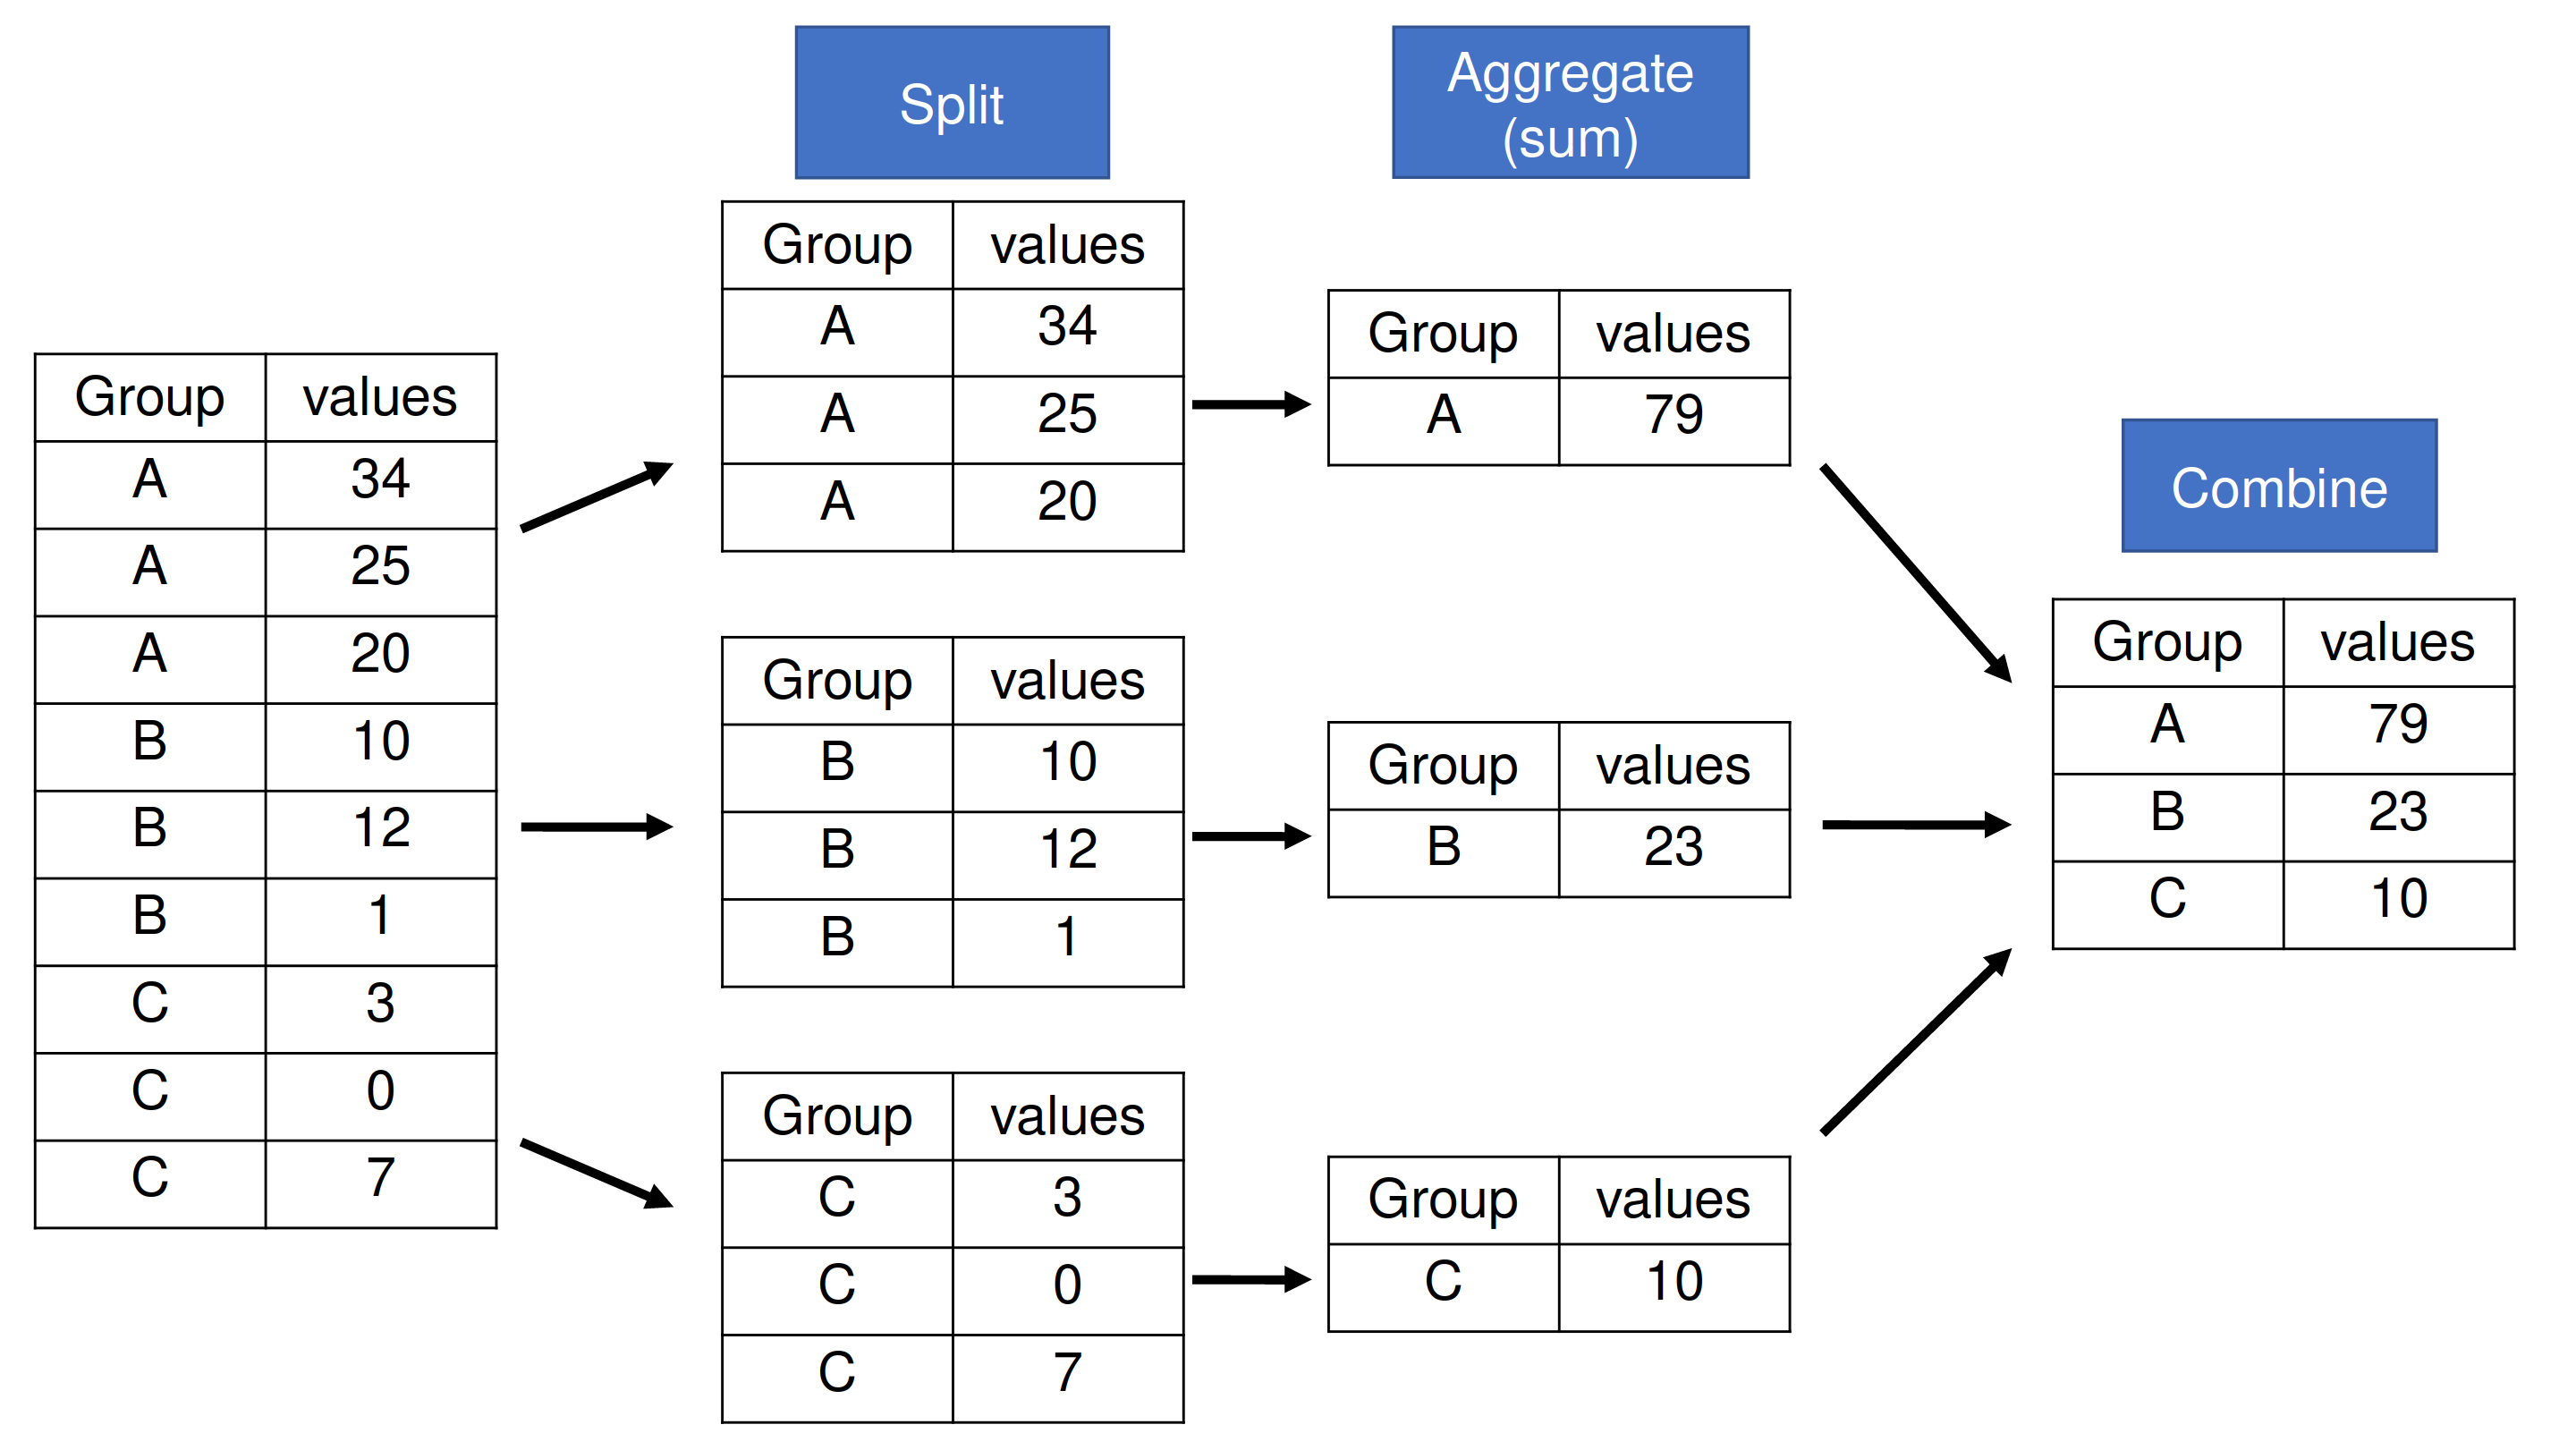
Source: https://www.dontusethiscode.com/blog/2022-09-21_groupby-split-apply-combine.html

In [176]:
#companies.headquarters_city = companies.headquarters_city.astype('category')  # converting to category speeds up processing
#companies.industry = companies.industry.astype('category')

In [190]:
#companies.groupby('industry')[['revenue','market_cap']].mean().sort_values(['revenue','market_cap'], ascending=[False, False])

#### Operations on Grouped Data  
- .agg(): Pass one or more functions that reduce data (e.g., mean). Shape of final result is different from original data  
    - The .agg() method applies different aggregation methods on different columns.  
    - Invoke the .agg() method directly on the DataFrameGroupBy object.  
    - Pass the method a dictionary where the keys are the columns and the values are the aggregation operations.  
- .transform(): Pass one or more reducing (e.g., mean) or non-reducing functions (e.g., cumsum). Final result has the same shape as original data  
- .apply(): Pass a reducing or non-reducing function to one or more variables.


In [191]:
#companies.groupby('industry')[['revenue','market_cap']].agg('mean','std')

,revenue,market_cap
industry,,
Advertising,1.008409e+10,2.146382e+10
Aerospace & Defense,3.302563e+10,1.118366e+11
Agricultural & Farm Machinery,4.568400e+10,1.574923e+11
Agricultural Products & Services,2.095000e+10,3.176773e+10
Air Freight & Logistics,5.097219e+10,5.348047e+10
...,...,...
Tobacco,3.196350e+10,1.992125e+11
Trading Companies & Distributors,5.947750e+09,6.030434e+10
Transaction & Payment Processing Services,1.240656e+10,1.652774e+11


In [192]:
# companies.groupby('industry')[['revenue','market_cap']].transform('mean')

,revenue,market_cap
0,1.735300e+10,1.078895e+11
1,1.231375e+10,4.077202e+10
2,1.294639e+10,5.581113e+10
3,2.133426e+10,1.248307e+11
4,2.818412e+10,1.033920e+11
...,...,...
498,8.994683e+09,3.392267e+10
499,1.687095e+10,6.996399e+10
500,6.197225e+09,3.221199e+10
501,1.294639e+10,5.581113e+10


In [193]:
# companies.groupby('industry')[['revenue','market_cap']].apply('mean')

,revenue,market_cap
industry,,
Advertising,1.008409e+10,2.146382e+10
Aerospace & Defense,3.302563e+10,1.118366e+11
Agricultural & Farm Machinery,4.568400e+10,1.574923e+11
Agricultural Products & Services,2.095000e+10,3.176773e+10
Air Freight & Logistics,5.097219e+10,5.348047e+10
...,...,...
Tobacco,3.196350e+10,1.992125e+11
Trading Companies & Distributors,5.947750e+09,6.030434e+10
Transaction & Payment Processing Services,1.240656e+10,1.652774e+11


### Pivot Table
- Create a spreadsheet-style pivot table as a DataFrame

In [194]:
#companies.pivot_table(index = 'industry',
#                    values=['revenue','market_cap'], 
#                    aggfunc='mean')

,market_cap,revenue
industry,,
Advertising,2.146382e+10,1.008409e+10
Aerospace & Defense,1.118366e+11,3.302563e+10
Agricultural & Farm Machinery,1.574923e+11,4.568400e+10
Agricultural Products & Services,3.176773e+10,2.095000e+10
Air Freight & Logistics,5.348047e+10,5.097219e+10
...,...,...
Tobacco,1.992125e+11,3.196350e+10
Trading Companies & Distributors,6.030434e+10,5.947750e+09
Transaction & Payment Processing Services,1.652774e+11,1.240656e+10


In [88]:
#companies.pivot_table(index = 'industry',
#                    values=['revenue','market_cap'], 
#                    aggfunc='mean'
#                     margins = True,
#                     margins_name = 'Overall_Mean')

,Profits_M,Revenues_M
Sector,,
Aerospace & Defense,1051.121053,20487.405263
Apparel,711.726667,8706.613333
Business Services,1030.001695,8331.708475
Chemicals,395.611538,10997.780769
Energy,2265.521698,21398.438318
Engineering & Construction,752.751613,9316.077419
Financials,2568.457669,22917.158282
Food & Drug Stores,538.833333,52199.144444
"Food, Beverages & Tobacco",1927.680000,19923.931429


## Visualize
- Pandas is built on top of numpy and matplotlib.
- As a result, a number of plotting functions are accessible as pandas methods.
- To illustrate, we will construct a histogram, bar chart and scatterplot. 

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# sns.histplot(data = companies, x = 'market_cap', bins=100);

# companies['market_cap'].plot(kind='hist', bins=100, title='Distribution of Market Capitalization')

In [ ]:
# companies_order = companies.groupby('headquarters_state')['market_cap'].mean().sort_values(ascending = False).index
# sns.barplot(data = companies, y = 'headquarters_state', x = 'market_cap',orient = 'h',order = companies_order);


# companies.groupby('headquarters_state')['market_cap'].mean().sort_values().plot(kind='barh', figsize=(10, 8), title='Mean Market Cap by Headquarters State')

In [ ]:
# companies.plot(x = 'revenue', y = 'market_cap', kind = 'scatter'); 

# companies.plot(x='revenue', y='market_cap', kind='scatter', title='Market Cap vs. Revenue')

## Summary  
This note examined methods for exploring data, a crucial first step in machine learning. 

In [92]:
#| echo: false
import platform
from IPython.display import display, HTML
import importlib.metadata
import sys

python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
os_info = f"{platform.system()} {platform.release()}"

libs = ['pandas','numpy','matplotlib']
# Create library list in the format: library version, library version
library_list = []
for lib_name in sorted(libs):
    library_list.append(f"{lib_name} {importlib.metadata.version(lib_name)}")
libraries_text = ", ".join(library_list)

# Create the formatted text
text = f"This file was generated using Python {python_version} on {os_info} with the following libraries: {libraries_text}"

# Display with HTML formatting
html = f"""
<hr style="border: 0; height: 1px; background: lightgray;" />
<p style="font-size: x-small; color: #555; background-color: #f8f8f8; padding: 8px; border-radius: 3px;">
{text}
</p>
"""
display(HTML(html))